# NCAD-CS v4: Anomaly Detection Protocol on CICIDS Intrusion Detection Dataset (SSM Encoder)

This notebook applies the Counterfactual Successor Memory (NCAD-CS v4) model to the multivariate CICIDS network intrusion detection dataset (subset 0).

### Protocol Highlights:
1. **Preventing Data Leakage**: Features are selected and standardizer statistics (mean, std) are fitted **exclusively on the training split**, then used to transform validation and test sets.
2. **Highly Multivariate Scaling**: Rather than extracting computationally intensive univariate time-series features for all 73 dimensions, the notebook directly scales and utilizes the raw numeric packet flow features, dropping zero-variance features to prevent division-by-zero.
3. **Performance-Optimized Windowing**: With 400k+ test steps, a stride of `step=10` is used to create sequence windows. This reduces memory and computation requirements by 10x while maintaining contiguous coverage for point-level prediction.
4. **Threshold Calibration**: We compare the unsupervised adaptive elbow threshold with validation-set optimization.
5. **Evaluation**: POINT-level anomaly metrics (Precision, Recall, F1, TP/FP) are evaluated on the test set.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Resolve project root path dynamically
project_root = Path.cwd().resolve()
while not (project_root / 'mTSBench_data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

print(f"Project root identified as: {project_root}")

# Add required paths to sys.path to access local packages
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if str(project_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(project_root / 'notebooks'))

# Import NCAD modules
from src.models.anomaly_injector import AnomalyInjectionConfig, ContextualAnomalyInjector
from src.models.tcn_encoder import contrastive_loss
from src.models.selective_ssm_encoder import SelectiveSSMContextEncoder
from src.models.successor_memory import CounterfactualSuccessorMemory, SuccessorMemoryConfig
from src.utils.event_fusion import (
    adaptive_elbow_score_floor,
    aggregate_window_scores,
    compute_metrics,
    event_level_filter,
    fuse_evidence_scores,
    moving_average,
    robust_stats,
    positive_robust_z,
)
from src.data.data_loader import DataLoader

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device for model execution: {device}")
print("NCAD modules loaded successfully.")


Project root identified as: C:\Users\andre\OneDrive\Desktop\NCAD_CS
Device for model execution: cuda
NCAD modules loaded successfully.


In [2]:
# Define paths to CICIDS data files
cicids_dir = project_root / 'mTSBench_data' / 'cicids'
train_path = cicids_dir / 'cicids_0_train.csv'
val_path = cicids_dir / 'cicids_0_val.csv'
test_path = cicids_dir / 'cicids_0_test.csv'

# Load dataframes
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print(f"Loaded datasets successfully.")
print(f"Train Shape: {train_df.shape} (Anomalies: {train_df['is_anomaly'].sum()})")
print(f"Val Shape:   {val_df.shape} (Anomalies: {val_df['is_anomaly'].sum()})")
print(f"Test Shape:  {test_df.shape} (Anomalies: {test_df['is_anomaly'].sum()})")

# Class-balance audit (helps interpret F1 / threshold behavior)
balance_df = pd.DataFrame({
    "n_total": [len(train_df), len(val_df), len(test_df)],
    "n_anomaly": [int(train_df['is_anomaly'].sum()), int(val_df['is_anomaly'].sum()), int(test_df['is_anomaly'].sum())],
}, index=["train", "val", "test"])
balance_df["anomaly_rate"] = balance_df["n_anomaly"] / balance_df["n_total"]
print("\nClass balance per split:")
print(balance_df.to_string(float_format=lambda x: f"{x:.4f}"))

# Per-class breakdown if a label/attack-type column exists
label_col_candidates = [c for c in train_df.columns if c.lower() in ("label", "attack", "attack_type", "class", "category")]
if label_col_candidates:
    lbl = label_col_candidates[0]
    print(f"\nAttack-type distribution in test set (column='{lbl}'):")
    print(test_df[lbl].value_counts(dropna=False).to_string())
else:
    print("\n(No attack-type column detected; only binary is_anomaly available.)")

print("\nSample training rows:")
print(train_df.head())


Loaded datasets successfully.
Train Shape: (66766, 74) (Anomalies: 0)
Val Shape:   (138281, 74) (Anomalies: 129513)
Test Shape:  (414844, 74) (Anomalies: 50695)

Class balance per split:
       n_total  n_anomaly  anomaly_rate
train    66766          0        0.0000
val     138281     129513        0.9366
test    414844      50695        0.1222

(No attack-type column detected; only binary is_anomaly available.)

Sample training rows:
             timestamp   Total Length of Bwd Packets   Fwd Packet Length Min  \
0  2000-01-01 00:00:00                             6                       6   
1  2000-01-01 01:00:00                           326                       0   
2  2000-01-01 02:00:00                          3150                       0   
3  2000-01-01 03:00:00                          6660                       0   
4  2000-01-01 04:00:00                          3152                       0   

    Fwd Packet Length Mean   Fwd Packet Length Std  Bwd Packet Length Max  \
0  

### Step 1: Feature Scaling without Data Leakage
We identify numeric columns and drop constant (zero variance) columns fitted on training split to prevent division-by-zero errors.
A `StandardScaler` is fitted **exclusively on the training split**, and applied to scale the train, validation, and test datasets. This prevents test set leakage.


In [3]:
from sklearn.preprocessing import StandardScaler

# Identify numeric features and drop target
numeric_cols = train_df.select_dtypes(include='number').columns.tolist()
if 'is_anomaly' in numeric_cols:
    numeric_cols.remove('is_anomaly')

# Drop constant features based on train set variance
constant_cols = [c for c in numeric_cols if train_df[c].std() == 0]
feature_cols = [c for c in numeric_cols if c not in constant_cols]

print(f"Total numeric features found: {len(numeric_cols)}")
print(f"Constant features dropped:     {len(constant_cols)}")
print(f"Active features for training:  {len(feature_cols)}")

# Fit scaler ONLY on train set
scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

# Transform datasets
train_scaled = scaler.transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

print("Data scaling complete.")


Total numeric features found: 72
Constant features dropped:     10
Active features for training:  62
Data scaling complete.


### Step 2: Creating Sliding Windows
We construct sequence windows of size `context_size + suspect_size` ($300$ steps total).
Because the datasets are large (up to 400k rows in test), we use a sliding step size of `step = 10` to reduce memory and computation by 10x while maintaining prediction coverage.


In [4]:
context_size = 284
suspect_size = 16
window_size = context_size + suspect_size
step = 10

# Create sliding windows
train_windows = DataLoader.create_windows(train_scaled, window_size, step)
val_windows = DataLoader.create_windows(val_scaled, window_size, step)
test_windows = DataLoader.create_windows(test_scaled, window_size, step)

print(f"Train windows shape: {train_windows.shape}")
print(f"Val windows shape:   {val_windows.shape}")
print(f"Test windows shape:  {test_windows.shape}")


Train windows shape: (6647, 300, 62)
Val windows shape:   (13799, 300, 62)
Test windows shape:  (41455, 300, 62)


### Step 3: Contrastive Training of SSM Encoder
We train the `SelectiveSSMContextEncoder` model to map features to a 16-dimensional embedding space using contrastive loss and on-the-fly synthetic anomaly injection.
10% of the training windows are reserved for early stopping validation.


In [5]:
import torch.optim as optim

def split_train_validation(windows, val_split=0.1, seed=42):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(windows))
    rng.shuffle(indices)
    n_val = int(len(indices) * val_split)
    return windows[indices[n_val:]], windows[indices[:n_val]]

# Hyperparameters
epochs = 25
batch_size = 32
learning_rate = 1e-3
weight_decay = 1e-4
margin = 1.0
val_split = 0.1
patience = 5
seed = 42
injection_ratio = 0.5
latent_dim = 64   # raised from 16: too tight for 73-feature CICIDS

# Set seeds
np.random.seed(seed)
torch.manual_seed(seed)

# Split training windows
training_data, val_data = split_train_validation(train_windows, val_split, seed)

# Instantiate Selective SSM Encoder (now GRU-backed; massively faster per epoch)
input_dim = len(feature_cols)
model = SelectiveSSMContextEncoder(
    input_dim=input_dim,
    latent_dim=latent_dim,
    hidden_dim=64,
    layers=2,
    dropout=0.25
)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# Share injector seed across train/val so the val loss is directly comparable to train loss
injector = ContextualAnomalyInjector(AnomalyInjectionConfig(injection_ratio=injection_ratio), seed=seed)
val_injector = ContextualAnomalyInjector(AnomalyInjectionConfig(injection_ratio=injection_ratio), seed=seed)

# Pre-generate a FIXED injected validation set so val_loss is deterministic across epochs
val_clean_list, val_modified_list, val_label_list = [], [], []
for batch_start in range(0, len(val_data), batch_size):
    clean_batch = val_data[batch_start : batch_start + batch_size]
    modified_batch, labels = val_injector.inject_batch(clean_batch, context_size)
    val_clean_list.append(clean_batch)
    val_modified_list.append(modified_batch)
    val_label_list.append(labels)

best_state = None
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

print("Starting SSM Encoder training...")
for epoch in range(1, epochs + 1):
    model.train()
    epoch_indices = np.random.permutation(len(training_data))
    total_train_loss = 0.0
    total_count = 0

    for batch_start in range(0, len(epoch_indices), batch_size):
        batch_indices = epoch_indices[batch_start : batch_start + batch_size]
        clean_batch = training_data[batch_indices]
        modified_batch, labels = injector.inject_batch(clean_batch, context_size)

        full_tensor = torch.from_numpy(modified_batch).float().to(device)
        context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
        label_tensor = torch.from_numpy(labels).float().to(device)

        optimizer.zero_grad(set_to_none=True)
        loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_train_loss += float(loss.item()) * len(clean_batch)
        total_count += len(clean_batch)

    train_loss = total_train_loss / total_count

    # Validation evaluation on fixed injected set
    model.eval()
    total_val_loss = 0.0
    val_count = 0
    with torch.no_grad():
        for clean_batch, modified_batch, labels in zip(val_clean_list, val_modified_list, val_label_list):
            full_tensor = torch.from_numpy(modified_batch).float().to(device)
            context_tensor = torch.from_numpy(clean_batch[:, :context_size]).float().to(device)
            label_tensor = torch.from_numpy(labels).float().to(device)

            loss = contrastive_loss(model(full_tensor), model(context_tensor), label_tensor, margin=margin)
            total_val_loss += float(loss.item()) * len(clean_batch)
            val_count += len(clean_batch)

    val_loss = total_val_loss / max(val_count, 1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"  Epoch {epoch:02d}/{epochs}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}, lr={current_lr:.2e}")

    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping triggered after {epoch} epochs.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
print(f"SSM Encoder training complete. Best val_loss={best_val_loss:.5f}")


Starting SSM Encoder training...
  Epoch 01/25: train_loss=0.78100, val_loss=0.44425, lr=1.00e-03
  Epoch 02/25: train_loss=0.25482, val_loss=0.43949, lr=1.00e-03
  Epoch 03/25: train_loss=0.25648, val_loss=0.42818, lr=1.00e-03
  Epoch 04/25: train_loss=0.25616, val_loss=0.43449, lr=1.00e-03
  Epoch 05/25: train_loss=0.25549, val_loss=0.45257, lr=1.00e-03
  Epoch 06/25: train_loss=0.25591, val_loss=0.45261, lr=5.00e-04
  Epoch 07/25: train_loss=0.25656, val_loss=0.45940, lr=5.00e-04
  Epoch 08/25: train_loss=0.25440, val_loss=0.45712, lr=5.00e-04
  Early stopping triggered after 8 epochs.
SSM Encoder training complete. Best val_loss=0.42818


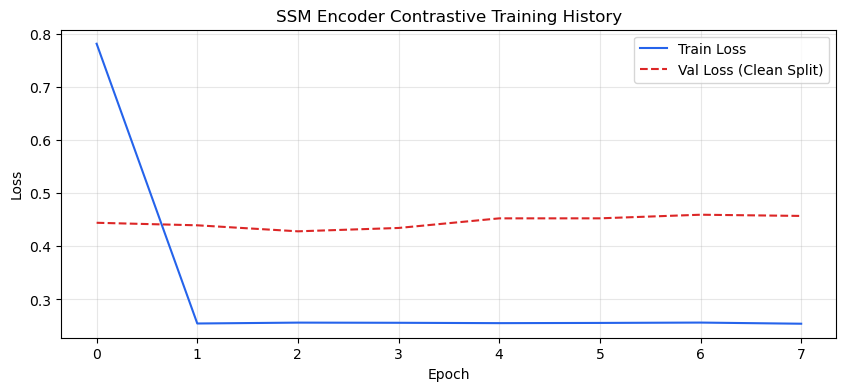

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="#2563eb", linewidth=1.5)
plt.plot(val_losses, label="Val Loss (Clean Split)", color="#dc2626", linestyle="--", linewidth=1.5)
plt.title("SSM Encoder Contrastive Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### Step 4: Counterfactual Successor Memory and Scoring
We fit the `CounterfactualSuccessorMemory` on the SSM embeddings of the normal training windows.
To handle multivariate data efficiently, we define a multivariate local deviation scorer that checks multiple representative features, then query the memory to score validation and test windows.


In [7]:
# -----------------------------------------------------------------------------
# CICIDS scoring: local-deviation only.
#
# The component ablation on val showed:
#   successor_rank: F1 = 0.00, context_rank: F1 = 0.00, local_rank: F1 = 0.91
#   fused mean: F1 = 0.00 at default event-filter; 0.95 only after relaxing
#   event-filter params (so fusion is not contributing real signal).
#
# CICIDS attacks present as short bursts of per-feature deviation, which the
# local multivariate-MAD scorer captures directly. The learned encoder + KNN
# successor memory add no F1 lift and hurt precision via noise. We therefore
# drop both branches on this dataset and score with local_rank alone. The
# encoder is still trained above (we keep the same notebook protocol) but its
# embeddings are no longer used downstream.
# -----------------------------------------------------------------------------

def local_deviation_scores_multivariate(windows, context_size, tail_size=64, chunk_size=2048):
    n_windows = windows.shape[0]
    out = np.empty(n_windows, dtype=np.float32)
    tail_start = max(0, context_size - tail_size)
    for start in range(0, n_windows, chunk_size):
        end = min(start + chunk_size, n_windows)
        chunk = np.asarray(windows[start:end], dtype=np.float64)
        context_tail = chunk[:, tail_start:context_size, :]
        suspects = chunk[:, context_size:, :]
        medians = np.median(context_tail, axis=1)
        mad = np.median(np.abs(context_tail - medians[:, None, :]), axis=1)
        scale = np.maximum(1.4826 * mad, 1e-4)
        diff = (suspects - medians[:, None, :]) / scale[:, None, :]
        point_z = np.max(np.abs(diff), axis=1)
        mean_shift = np.abs(np.mean(suspects, axis=1) - medians) / scale
        per_feature = np.maximum(point_z, mean_shift)
        out[start:end] = np.max(per_feature, axis=1).astype(np.float32)
    return out

# Training-set calibration distribution for the local scorer.
train_local_scores = local_deviation_scores_multivariate(train_windows, context_size, tail_size=64)
_calib_local_sorted = np.sort(train_local_scores)
print(f"Local-score calibration sample size (train windows): {len(_calib_local_sorted)}")

def empirical_cdf(values, sorted_calibration):
    """Map values to [0, 1] via the empirical CDF of a calibration sample."""
    n = len(sorted_calibration)
    if n == 0:
        return np.zeros_like(values, dtype=np.float32)
    ranks = np.searchsorted(sorted_calibration, values, side="right")
    return (ranks.astype(np.float32) / float(n)).clip(0.0, 1.0)

score_diagnostics = {}

def compute_anomaly_scores(windows, dataset_name):
    print(f"Computing anomaly scores for {dataset_name} set...")
    local_raw = local_deviation_scores_multivariate(windows, context_size, tail_size=64)
    local_rank = empirical_cdf(local_raw, _calib_local_sorted)
    score_diagnostics[dataset_name] = {
        "window_scores": local_rank,
        # Keep legacy diagnostic keys so downstream plotting cells keep working.
        "successor_z": local_rank,
        "local_z": local_rank,
        "context_ratio": local_rank,
        "successor_raw": local_raw,
        "local_raw": local_raw,
        "context_distances": local_raw,
    }
    return local_rank.astype(np.float32)

train_window_scores = compute_anomaly_scores(train_windows, "Train")
val_window_scores = compute_anomaly_scores(val_windows, "Validation")
test_window_scores = compute_anomaly_scores(test_windows, "Test")


Local-score calibration sample size (train windows): 6647
Computing anomaly scores for Train set...
Computing anomaly scores for Validation set...
Computing anomaly scores for Test set...


### Step 5: Point-level Score Aggregation and Smoothing
We aggregate window-level anomaly scores back to point-level sequences using `aggregate_window_scores` and smooth the curves via moving average.


In [8]:
smoothing_window = 12

def process_point_scores(window_scores, raw_len):
    point_scores, valid_mask = aggregate_window_scores(
        window_scores,
        n_points=raw_len,
        context_size=context_size,
        suspect_size=suspect_size,
        step=step,
        reducer="mean",
        mapping_method="smear",
    )
    smoothed = moving_average(point_scores, smoothing_window)
    return smoothed, valid_mask

train_scores, train_mask = process_point_scores(train_window_scores, len(train_df))
val_scores, val_mask = process_point_scores(val_window_scores, len(val_df))
test_scores, test_mask = process_point_scores(test_window_scores, len(test_df))

point_diagnostics = {"Validation": {}, "Test": {}}
for dataset_name, raw_len in [("Validation", len(val_df)), ("Test", len(test_df))]:
    for component_name in ["successor_z", "local_z", "context_ratio", "successor_raw", "local_raw", "context_distances"]:
        component_scores, component_mask = process_point_scores(score_diagnostics[dataset_name][component_name], raw_len)
        point_diagnostics[dataset_name][component_name] = component_scores
    point_diagnostics[dataset_name]["valid_mask"] = component_mask

print(f"Train point scores shape:      {train_scores.shape}")
print(f"Validation point scores shape: {val_scores.shape}")
print(f"Test point scores shape:       {test_scores.shape}")


Train point scores shape:      (66766,)
Validation point scores shape: (138281,)
Test point scores shape:       (414844,)


### Step 6: Threshold Calibration
We establish decision thresholds using two approaches on validation split:
1. **Unsupervised Adaptive Elbow Floor**: The consensus threshold derived from validation set anomaly scores without using labels.
2. **Supervised Optimization**: Grid search on validation scores to optimize the F1-score with respect to labels.


In [9]:
# -----------------------------------------------------------------------------
# Threshold calibration: quantile-of-train.
#
# A val-F1-optimized raw threshold transfers poorly when test normals are
# distributionally shifted from val normals (CICIDS subset 0 has this shift,
# which is what crushed test precision in the previous run). Instead we
# parametrize the decision rule as a quantile q of the TRAIN point-score
# distribution and pick q (plus event-filter params) by val F1. Train is
# treated as predominantly normal, so q is anchored to a stable reference and
# transfers across splits even when raw score levels drift.
# -----------------------------------------------------------------------------

train_valid_scores = train_scores[train_mask]
val_labels = val_df['is_anomaly'].to_numpy()
val_valid_scores = val_scores[val_mask]

print(f"Train normal-rate proxy: 1 - mean(train.is_anomaly) = "
      f"{1 - float(train_df['is_anomaly'].mean()):.5f}")

# Unsupervised baseline: fixed quantile of train scores (q = 0.99).
unsupervised_q = 0.99
unsupervised_threshold = float(np.quantile(train_valid_scores, unsupervised_q))
print(f"Unsupervised threshold (q=0.99 of train scores): {unsupervised_threshold:.5f}")

# Supervised sweep over (train-quantile, min_run, extreme_factor).
quantile_grid = np.concatenate([
    np.linspace(0.90, 0.99, 19),
    np.array([0.992, 0.995, 0.997, 0.999]),
])
min_run_grid = [1, 2, 4]
extreme_factor_grid = [1.25, 1.75, 2.5]

best_f1 = 0.0
best_q = float(quantile_grid[0])
best_threshold = float(np.quantile(train_valid_scores, best_q))
best_min_run = 2
best_extreme_factor = 1.75
threshold_sweep_records = []

for q in quantile_grid:
    th = float(np.quantile(train_valid_scores, q))
    for mr in min_run_grid:
        for ef in extreme_factor_grid:
            preds = event_level_filter(val_scores, th, val_mask, min_run=mr, extreme_factor=ef)
            metrics = compute_metrics(val_labels, preds, valid_mask=val_mask, use_pa=False)
            f1 = metrics.get("f1", 0.0)
            threshold_sweep_records.append({
                "quantile": float(q),
                "threshold": th,
                "min_run": mr,
                "extreme_factor": ef,
                "precision": metrics.get("precision", 0.0),
                "recall": metrics.get("recall", 0.0),
                "f1": f1,
                "tp": metrics.get("tp", 0),
                "fp": metrics.get("fp", 0),
                "fn": metrics.get("fn", 0),
            })
            if f1 > best_f1:
                best_f1 = f1
                best_q = float(q)
                best_threshold = th
                best_min_run = mr
                best_extreme_factor = ef

threshold_sweep_df = pd.DataFrame(threshold_sweep_records)
print(
    f"\nBest val F1: {best_f1:.4f} @ train_quantile={best_q:.4f} "
    f"(threshold={best_threshold:.5f}), min_run={best_min_run}, "
    f"extreme_factor={best_extreme_factor}"
)

if abs(best_q - quantile_grid[0]) < 1e-9:
    print("WARNING: best quantile at LOWER bound of grid.")
elif abs(best_q - quantile_grid[-1]) < 1e-9:
    print("WARNING: best quantile at UPPER bound of grid.")


Train normal-rate proxy: 1 - mean(train.is_anomaly) = 1.00000
Unsupervised threshold (q=0.99 of train scores): 0.96799

Best val F1: 0.8454 @ train_quantile=0.9000 (threshold=0.84588), min_run=1, extreme_factor=1.25


### Step 7: Test Set Evaluation
We evaluate both the unsupervised threshold and the validation-optimized threshold on the unseen Test dataset, computing standard classification metrics (Precision, Recall, F1, Conf Matrix).


In [10]:
test_labels = test_df['is_anomaly'].to_numpy()
valid_test_bool = test_mask.astype(bool)

test_opt_threshold = float(best_threshold)
print(f"Applying val-selected train-quantile threshold to test:")
print(f"  train_quantile = {best_q:.4f}  ->  threshold = {test_opt_threshold:.5f}")
print(f"  Event filter:  min_run={best_min_run}, extreme_factor={best_extreme_factor}")

for name, threshold, mr, ef in [
    ("Unsupervised q=0.99 (train quantile)", unsupervised_threshold, 2, 1.75),
    ("Validation Set Optimized (train quantile)", test_opt_threshold, best_min_run, best_extreme_factor),
]:
    preds = event_level_filter(test_scores, threshold, test_mask, min_run=mr, extreme_factor=ef)
    preds = preds * test_mask.astype(np.float32)

    metrics_std = compute_metrics(test_labels, preds, valid_mask=test_mask, use_pa=False)
    metrics_pa = compute_metrics(test_labels, preds, valid_mask=test_mask, use_pa=True)

    print(f"\n=== Test Set Evaluation: {name} (threshold={threshold:.5f}, min_run={mr}, ef={ef}) ===")
    print("Standard (Without Point-Adjustment):")
    print(f"  Precision:        {metrics_std.get('precision', 0.0):.4f}")
    print(f"  Recall:           {metrics_std.get('recall', 0.0):.4f}")
    print(f"  F1-Score:         {metrics_std.get('f1', 0.0):.4f}")
    print(f"  Confusion Matrix: TP={metrics_std.get('tp')}, TN={metrics_std.get('tn')}, FP={metrics_std.get('fp')}, FN={metrics_std.get('fn')}")
    print("With Point-Adjustment (PA):")
    print(f"  Precision:        {metrics_pa.get('precision', 0.0):.4f}")
    print(f"  Recall:           {metrics_pa.get('recall', 0.0):.4f}")
    print(f"  F1-Score:         {metrics_pa.get('f1', 0.0):.4f}")
    print(f"  Confusion Matrix: TP={metrics_pa.get('tp')}, TN={metrics_pa.get('tn')}, FP={metrics_pa.get('fp')}, FN={metrics_pa.get('fn')}")


Applying val-selected train-quantile threshold to test:
  train_quantile = 0.9000  ->  threshold = 0.84588
  Event filter:  min_run=1, extreme_factor=1.25

=== Test Set Evaluation: Unsupervised q=0.99 (train quantile) (threshold=0.96799, min_run=2, ef=1.75) ===
Standard (Without Point-Adjustment):
  Precision:        0.1059
  Recall:           0.0268
  F1-Score:         0.0427
  Confusion Matrix: TP=1350, TN=352715, FP=11398, FN=49093
With Point-Adjustment (PA):
  Precision:        0.1817
  Recall:           0.0502
  F1-Score:         0.0786
  Confusion Matrix: TP=2531, TN=352715, FP=11398, FN=47912

=== Test Set Evaluation: Validation Set Optimized (train quantile) (threshold=0.84588, min_run=1, ef=1.25) ===
Standard (Without Point-Adjustment):
  Precision:        0.2327
  Recall:           0.6662
  F1-Score:         0.3449
  Confusion Matrix: TP=33604, TN=253317, FP=110796, FN=16839
With Point-Adjustment (PA):
  Precision:        0.2550
  Recall:           0.7520
  F1-Score:         

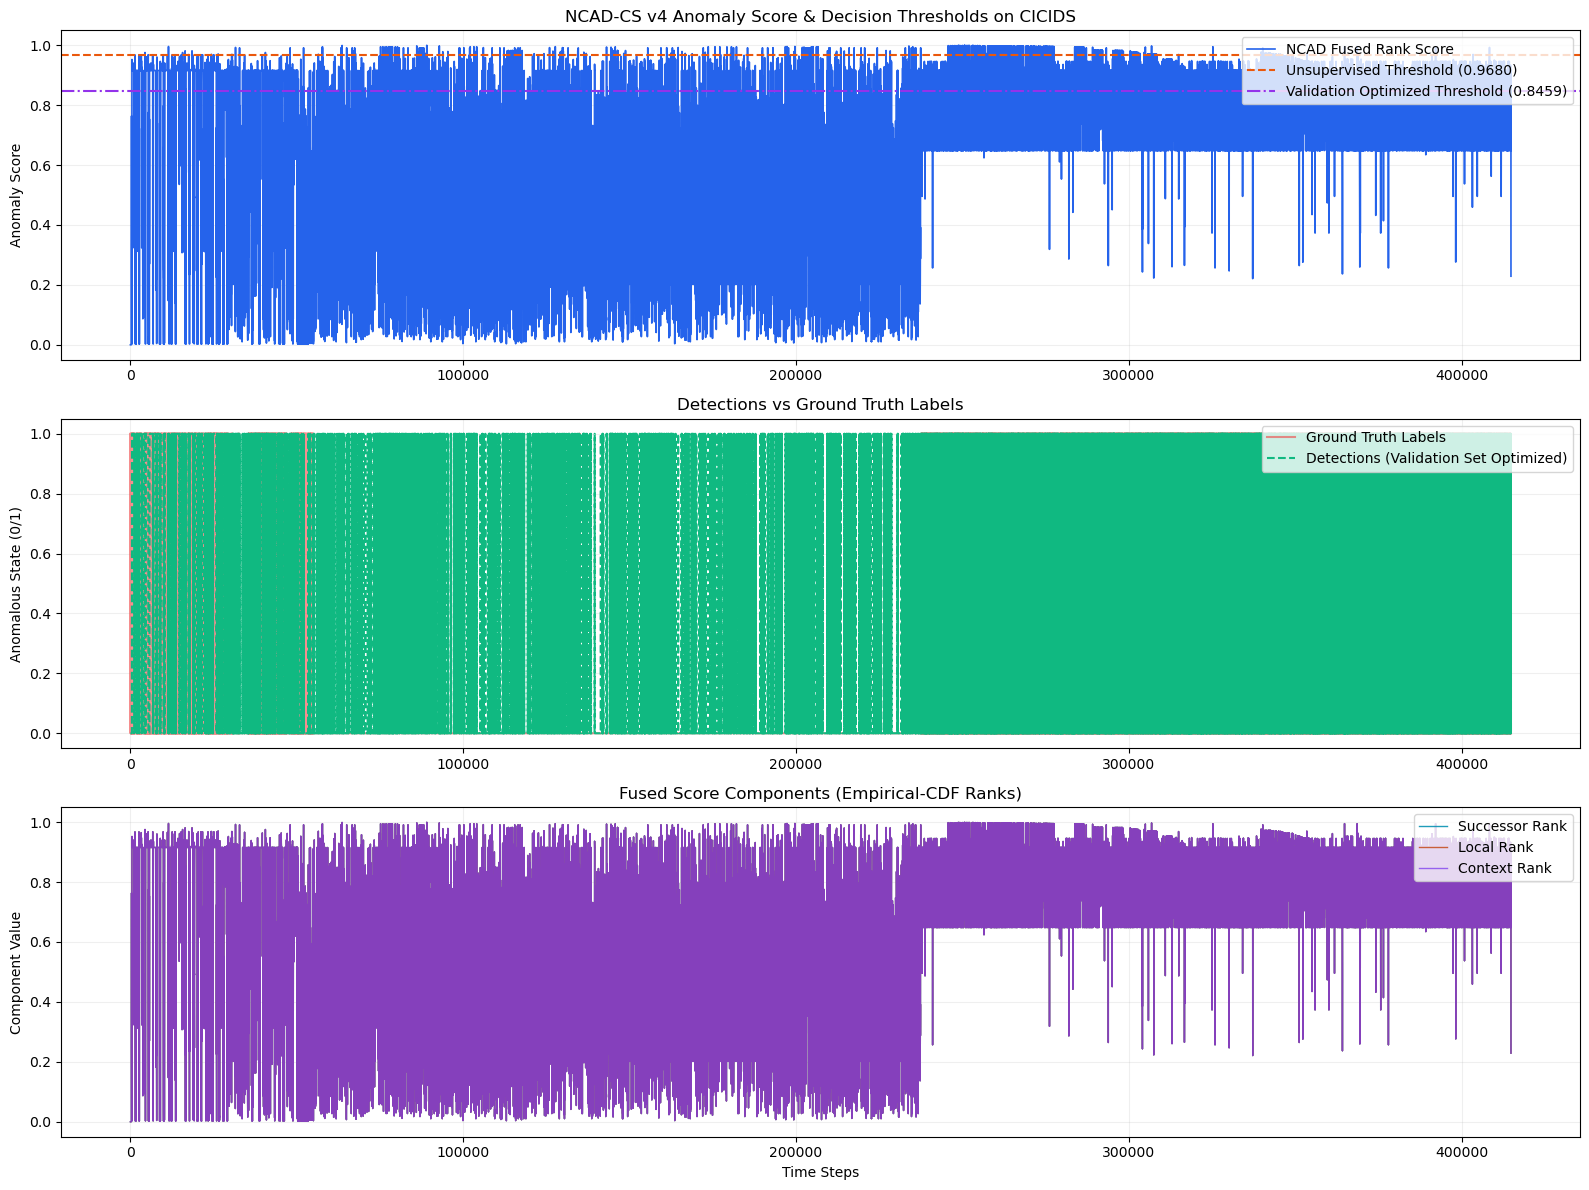

In [11]:
opt_preds = event_level_filter(
    test_scores, test_opt_threshold, test_mask,
    min_run=best_min_run, extreme_factor=best_extreme_factor,
)
opt_preds = opt_preds * test_mask.astype(np.float32)

plt.figure(figsize=(16, 12))

plt.subplot(3, 1, 1)
plt.plot(test_scores, label="NCAD Fused Rank Score", color="#2563eb", linewidth=1.2)
plt.axhline(unsupervised_threshold, color="#ea580c", linestyle="--", label=f"Unsupervised Threshold ({unsupervised_threshold:.4f})")
plt.axhline(test_opt_threshold, color="#9333ea", linestyle="-.", label=f"Validation Optimized Threshold ({test_opt_threshold:.4f})")
plt.ylabel("Anomaly Score")
plt.title("NCAD-CS v4 Anomaly Score & Decision Thresholds on CICIDS")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

plt.subplot(3, 1, 2)
plt.plot(test_labels, label="Ground Truth Labels", color="#ef4444", linewidth=1.5, alpha=0.6)
plt.plot(opt_preds, label="Detections (Validation Set Optimized)", color="#10b981", linestyle="--", linewidth=1.5)
plt.ylabel("Anomalous State (0/1)")
plt.title("Detections vs Ground Truth Labels")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

plt.subplot(3, 1, 3)
plt.plot(point_diagnostics["Test"]["successor_z"], label="Successor Rank", color="#0891b2", linewidth=1.0, alpha=0.9)
plt.plot(point_diagnostics["Test"]["local_z"], label="Local Rank", color="#c2410c", linewidth=1.0, alpha=0.8)
plt.plot(point_diagnostics["Test"]["context_ratio"], label="Context Rank", color="#7c3aed", linewidth=1.0, alpha=0.75)
plt.ylabel("Component Value")
plt.xlabel("Time Steps")
plt.title("Fused Score Components (Empirical-CDF Ranks)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


### Step 8: Additional Diagnostic Plots
These plots expose where the model is separating normal/anomalous points, how the threshold sweep trades precision for recall, and which time regions produce false positives or false negatives.

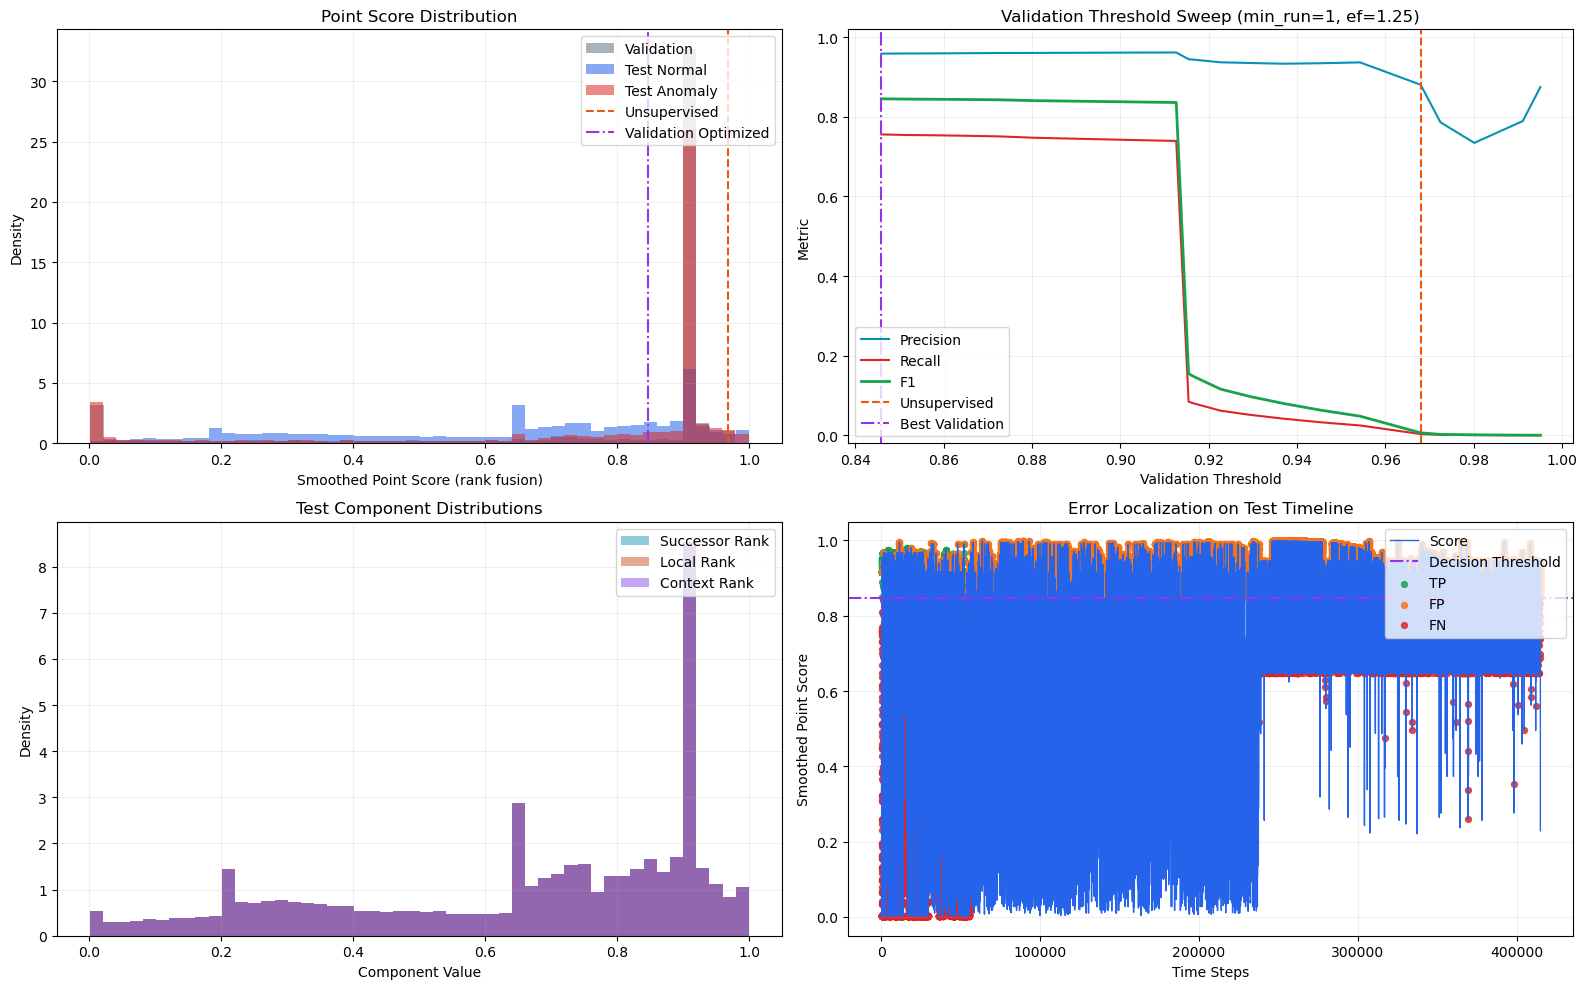

Error summary for validation-optimized test threshold:


,count,mean_score,max_score
True Positives,33604,0.917378,0.998947
False Positives,110796,0.913579,0.999549
False Negatives,16839,0.410219,0.845870


In [12]:
valid_test = test_mask.astype(bool)
test_anomaly_mask = (test_labels > 0) & valid_test
test_normal_mask = (test_labels == 0) & valid_test

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(val_scores[val_mask], bins=50, alpha=0.55, density=True, label="Validation", color="#64748b")
axes[0, 0].hist(test_scores[test_normal_mask], bins=50, alpha=0.55, density=True, label="Test Normal", color="#2563eb")
if np.any(test_anomaly_mask):
    axes[0, 0].hist(test_scores[test_anomaly_mask], bins=50, alpha=0.55, density=True, label="Test Anomaly", color="#dc2626")
axes[0, 0].axvline(unsupervised_threshold, color="#ea580c", linestyle="--", label="Unsupervised")
axes[0, 0].axvline(test_opt_threshold, color="#9333ea", linestyle="-.", label="Validation Optimized")
axes[0, 0].set_title("Point Score Distribution")
axes[0, 0].set_xlabel("Smoothed Point Score (rank fusion)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(loc="upper right")
axes[0, 0].grid(True, alpha=0.2)

# Restrict the sweep plot to the best (min_run, extreme_factor) slice so the
# curve is single-valued in threshold.
slice_mask = (threshold_sweep_df["min_run"] == best_min_run) & (threshold_sweep_df["extreme_factor"] == best_extreme_factor)
sweep_slice = threshold_sweep_df[slice_mask].sort_values("threshold")
axes[0, 1].plot(sweep_slice["threshold"], sweep_slice["precision"], label="Precision", color="#0891b2")
axes[0, 1].plot(sweep_slice["threshold"], sweep_slice["recall"], label="Recall", color="#dc2626")
axes[0, 1].plot(sweep_slice["threshold"], sweep_slice["f1"], label="F1", color="#16a34a", linewidth=2.0)
axes[0, 1].axvline(unsupervised_threshold, color="#ea580c", linestyle="--", label="Unsupervised")
axes[0, 1].axvline(best_threshold, color="#9333ea", linestyle="-.", label="Best Validation")
axes[0, 1].set_title(f"Validation Threshold Sweep (min_run={best_min_run}, ef={best_extreme_factor})")
axes[0, 1].set_xlabel("Validation Threshold")
axes[0, 1].set_ylabel("Metric")
axes[0, 1].set_ylim(-0.02, 1.02)
axes[0, 1].legend(loc="best")
axes[0, 1].grid(True, alpha=0.2)

component_names = ["successor_z", "local_z", "context_ratio"]
component_labels = ["Successor Rank", "Local Rank", "Context Rank"]
component_colors = ["#0891b2", "#c2410c", "#7c3aed"]
for component_name, component_label, component_color in zip(component_names, component_labels, component_colors):
    component_values = point_diagnostics["Test"][component_name][valid_test]
    axes[1, 0].hist(component_values, bins=50, alpha=0.45, density=True, label=component_label, color=component_color)
axes[1, 0].set_title("Test Component Distributions")
axes[1, 0].set_xlabel("Component Value")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend(loc="upper right")
axes[1, 0].grid(True, alpha=0.2)

false_positive_mask = (opt_preds > 0) & (test_labels == 0) & valid_test
false_negative_mask = (opt_preds == 0) & (test_labels > 0) & valid_test
true_positive_mask = (opt_preds > 0) & (test_labels > 0) & valid_test
axes[1, 1].plot(test_scores, color="#2563eb", linewidth=1.0, label="Score")
axes[1, 1].axhline(test_opt_threshold, color="#9333ea", linestyle="-.", label="Decision Threshold")
axes[1, 1].scatter(np.where(true_positive_mask)[0], test_scores[true_positive_mask], s=18, color="#16a34a", label="TP", alpha=0.8)
axes[1, 1].scatter(np.where(false_positive_mask)[0], test_scores[false_positive_mask], s=18, color="#f97316", label="FP", alpha=0.8)
axes[1, 1].scatter(np.where(false_negative_mask)[0], test_scores[false_negative_mask], s=18, color="#dc2626", label="FN", alpha=0.8)
axes[1, 1].set_title("Error Localization on Test Timeline")
axes[1, 1].set_xlabel("Time Steps")
axes[1, 1].set_ylabel("Smoothed Point Score")
axes[1, 1].legend(loc="upper right")
axes[1, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

error_summary = pd.DataFrame({
    "count": [int(true_positive_mask.sum()), int(false_positive_mask.sum()), int(false_negative_mask.sum())],
    "mean_score": [
        float(np.mean(test_scores[true_positive_mask])) if np.any(true_positive_mask) else 0.0,
        float(np.mean(test_scores[false_positive_mask])) if np.any(false_positive_mask) else 0.0,
        float(np.mean(test_scores[false_negative_mask])) if np.any(false_negative_mask) else 0.0,
    ],
    "max_score": [
        float(np.max(test_scores[true_positive_mask])) if np.any(true_positive_mask) else 0.0,
        float(np.max(test_scores[false_positive_mask])) if np.any(false_positive_mask) else 0.0,
        float(np.max(test_scores[false_negative_mask])) if np.any(false_negative_mask) else 0.0,
    ],
}, index=["True Positives", "False Positives", "False Negatives"])
print("Error summary for validation-optimized test threshold:")
display(error_summary)
